In [ ]:
#This noteboot is about SVM 

import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
%matplotlib inline

In [ ]:
df=pd.read_csv("diamonds.csv") 
df.head(15)                                  

,Unnamed: 0,carat,cut,color,clarity,depth,table,price,x,y,z
0,1,0.23,Ideal,E,SI2,61.5,55.0,326,3.95,3.98,2.43
1,2,0.21,Premium,E,SI1,59.8,61.0,326,3.89,3.84,2.31
2,3,0.23,Good,E,VS1,56.9,65.0,327,4.05,4.07,2.31
3,4,0.29,Premium,I,VS2,62.4,58.0,334,4.20,4.23,2.63
4,5,0.31,Good,J,SI2,63.3,58.0,335,4.34,4.35,2.75
5,6,0.24,Very Good,J,VVS2,62.8,57.0,336,3.94,3.96,2.48
6,7,0.24,Very Good,I,VVS1,62.3,57.0,336,3.95,3.98,2.47
7,8,0.26,Very Good,H,SI1,61.9,55.0,337,4.07,4.11,2.53
8,9,0.22,Fair,E,VS2,65.1,61.0,337,3.87,3.78,2.49
9,10,0.23,Very Good,H,VS1,59.4,61.0,338,4.00,4.05,2.39


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 53940 entries, 0 to 53939
Data columns (total 11 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   Unnamed: 0  53940 non-null  int64  
 1   carat       53940 non-null  float64
 2   cut         53940 non-null  object 
 3   color       53940 non-null  object 
 4   clarity     53940 non-null  object 
 5   depth       53940 non-null  float64
 6   table       53940 non-null  float64
 7   price       53940 non-null  int64  
 8   x           53940 non-null  float64
 9   y           53940 non-null  float64
 10  z           53940 non-null  float64
dtypes: float64(6), int64(2), object(3)
memory usage: 4.5+ MB


In [ ]:
df.drop("Unnamed: 0", axis=1)

,carat,cut,color,clarity,depth,table,price,x,y,z
0,0.23,Ideal,E,SI2,61.5,55.0,326,3.95,3.98,2.43
1,0.21,Premium,E,SI1,59.8,61.0,326,3.89,3.84,2.31
2,0.23,Good,E,VS1,56.9,65.0,327,4.05,4.07,2.31
3,0.29,Premium,I,VS2,62.4,58.0,334,4.20,4.23,2.63
4,0.31,Good,J,SI2,63.3,58.0,335,4.34,4.35,2.75
...,...,...,...,...,...,...,...,...,...,...
53935,0.72,Ideal,D,SI1,60.8,57.0,2757,5.75,5.76,3.50
53936,0.72,Good,D,SI1,63.1,55.0,2757,5.69,5.75,3.61
53937,0.70,Very Good,D,SI1,62.8,60.0,2757,5.66,5.68,3.56
53938,0.86,Premium,H,SI2,61.0,58.0,2757,6.15,6.12,3.74


In [ ]:
df.describe()

,Unnamed: 0,carat,depth,table,price,x,y,z
count,53940.000000,53940.000000,53940.000000,53940.000000,53940.000000,53940.000000,53940.000000,53940.000000
mean,26970.500000,0.797940,61.749405,57.457184,3932.799722,5.731157,5.734526,3.538734
std,15571.281097,0.474011,1.432621,2.234491,3989.439738,1.121761,1.142135,0.705699
min,1.000000,0.200000,43.000000,43.000000,326.000000,0.000000,0.000000,0.000000
25%,13485.750000,0.400000,61.000000,56.000000,950.000000,4.710000,4.720000,2.910000
50%,26970.500000,0.700000,61.800000,57.000000,2401.000000,5.700000,5.710000,3.530000
75%,40455.250000,1.040000,62.500000,59.000000,5324.250000,6.540000,6.540000,4.040000
max,53940.000000,5.010000,79.000000,95.000000,18823.000000,10.740000,58.900000,31.800000


In [ ]:
df[df["x"]==0].value_counts() #we should delete this wrong data

Unnamed: 0  carat  cut        color  clarity  depth  table  price  x    y     z  
11183       1.07   Ideal      F      SI2      61.6   56.0   4954   0.0  6.62  0.0    1
11964       1.00   Very Good  H      VS2      63.3   53.0   5139   0.0  0.00  0.0    1
15952       1.14   Fair       G      VS1      57.5   67.0   6381   0.0  0.00  0.0    1
24521       1.56   Ideal      G      VS2      62.2   54.0   12800  0.0  0.00  0.0    1
26244       1.20   Premium    D      VVS1     62.1   59.0   15686  0.0  0.00  0.0    1
27430       2.25   Premium    H      SI2      62.8   59.0   18034  0.0  0.00  0.0    1
49557       0.71   Good       F      SI2      64.1   60.0   2130   0.0  0.00  0.0    1
49558       0.71   Good       F      SI2      64.1   60.0   2130   0.0  0.00  0.0    1
Name: count, dtype: int64

In [ ]:
df[df["y"]==0].value_counts()

Unnamed: 0  carat  cut        color  clarity  depth  table  price  x    y    z  
11964       1.00   Very Good  H      VS2      63.3   53.0   5139   0.0  0.0  0.0    1
15952       1.14   Fair       G      VS1      57.5   67.0   6381   0.0  0.0  0.0    1
24521       1.56   Ideal      G      VS2      62.2   54.0   12800  0.0  0.0  0.0    1
26244       1.20   Premium    D      VVS1     62.1   59.0   15686  0.0  0.0  0.0    1
27430       2.25   Premium    H      SI2      62.8   59.0   18034  0.0  0.0  0.0    1
49557       0.71   Good       F      SI2      64.1   60.0   2130   0.0  0.0  0.0    1
49558       0.71   Good       F      SI2      64.1   60.0   2130   0.0  0.0  0.0    1
Name: count, dtype: int64

In [ ]:
df[df["z"]==0].value_counts() #len(df[df["x"]==0].value_counts())

Unnamed: 0  carat  cut        color  clarity  depth  table  price  x     y     z  
2208        1.00   Premium    G      SI2      59.1   59.0   3142   6.55  6.48  0.0    1
2315        1.01   Premium    H      I1       58.1   59.0   3167   6.66  6.60  0.0    1
4792        1.10   Premium    G      SI2      63.0   59.0   3696   6.50  6.47  0.0    1
5472        1.01   Premium    F      SI2      59.2   58.0   3837   6.50  6.47  0.0    1
10168       1.50   Good       G      I1       64.0   61.0   4731   7.15  7.04  0.0    1
11183       1.07   Ideal      F      SI2      61.6   56.0   4954   0.00  6.62  0.0    1
11964       1.00   Very Good  H      VS2      63.3   53.0   5139   0.00  0.00  0.0    1
13602       1.15   Ideal      G      VS2      59.2   56.0   5564   6.88  6.83  0.0    1
15952       1.14   Fair       G      VS1      57.5   67.0   6381   0.00  0.00  0.0    1
24395       2.18   Premium    H      SI2      59.4   61.0   12631  8.49  8.45  0.0    1
24521       1.56   Ideal      G      

In [ ]:
df=df.drop(df[df["x"]==0].index) 
df=df.drop(df[df["y"]==0].index)
df=df.drop(df[df["z"]==0].index)
df.describe()

,Unnamed: 0,carat,depth,table,price,x,y,z
count,53920.000000,53920.000000,53920.000000,53920.000000,53920.000000,53920.000000,53920.000000,53920.000000
mean,26972.355731,0.797698,61.749514,57.456834,3930.993231,5.731627,5.734887,3.540046
std,15571.269010,0.473795,1.432331,2.234064,3987.280446,1.119423,1.140126,0.702530
min,1.000000,0.200000,43.000000,43.000000,326.000000,3.730000,3.680000,1.070000
25%,13487.750000,0.400000,61.000000,56.000000,949.000000,4.710000,4.720000,2.910000
50%,26973.500000,0.700000,61.800000,57.000000,2401.000000,5.700000,5.710000,3.530000
75%,40457.250000,1.040000,62.500000,59.000000,5323.250000,6.540000,6.540000,4.040000
max,53940.000000,5.010000,79.000000,95.000000,18823.000000,10.740000,58.900000,31.800000


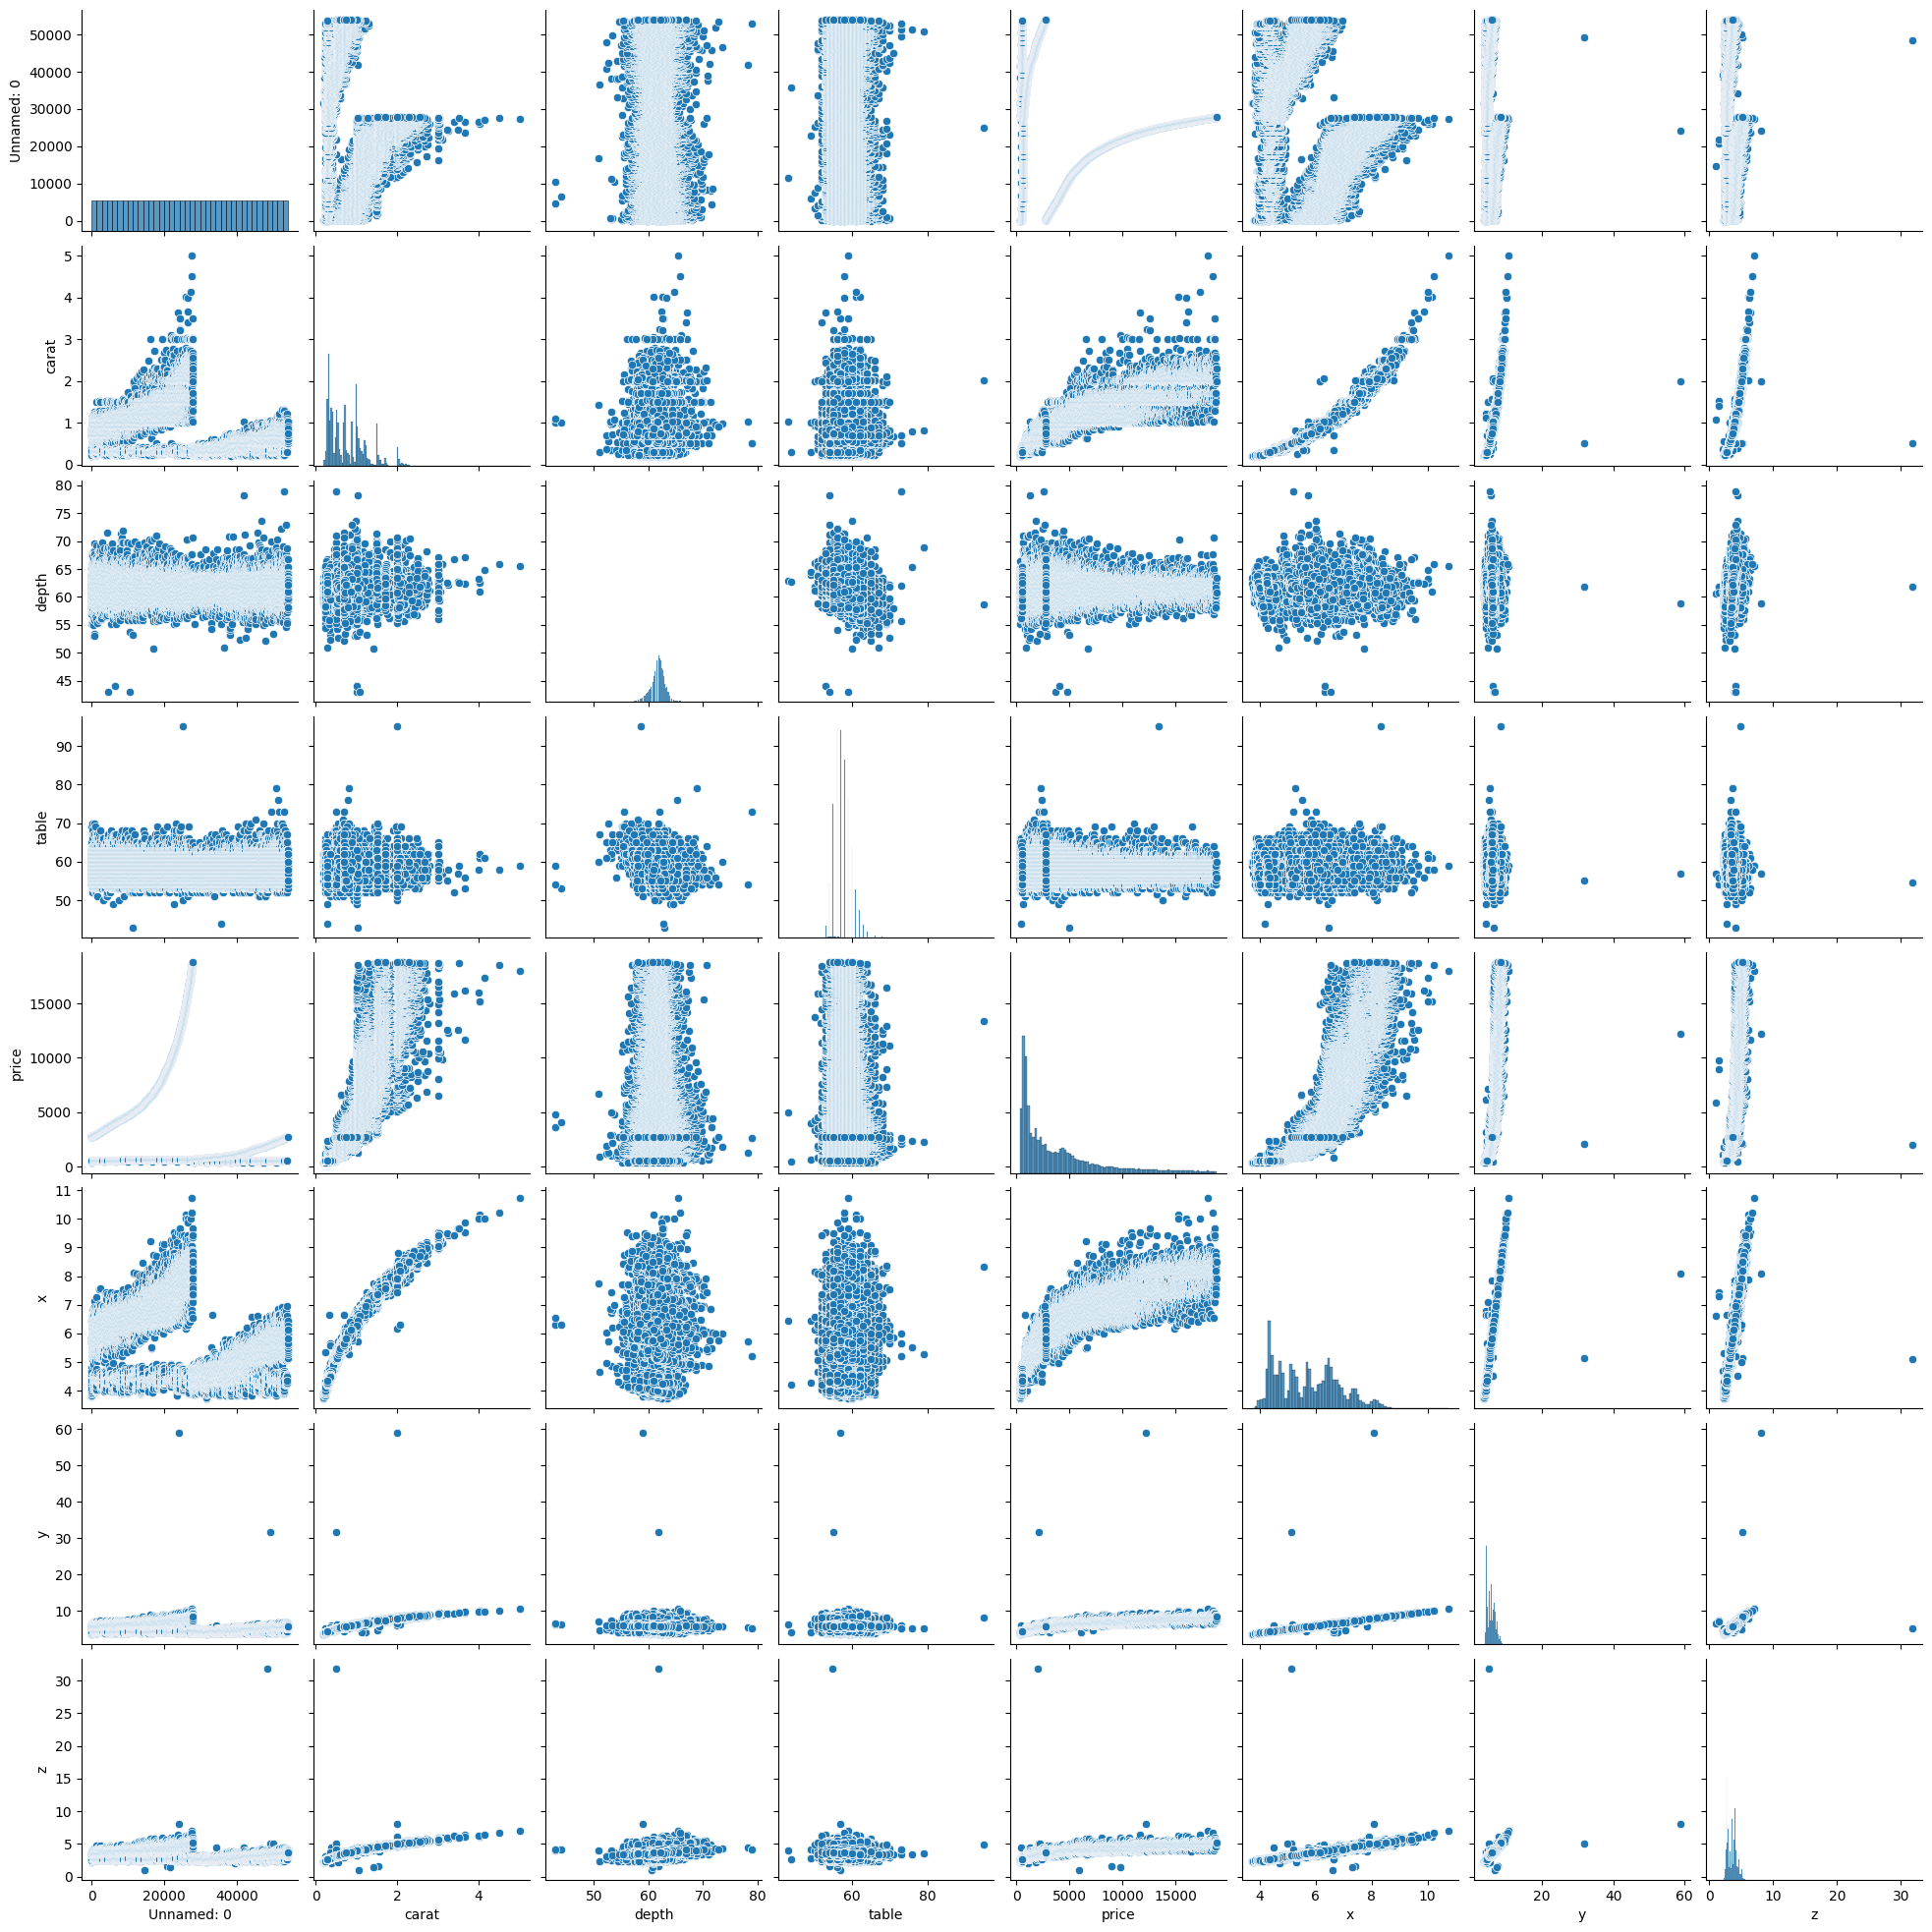

In [ ]:
sns.pairplot(df)
plt.show()

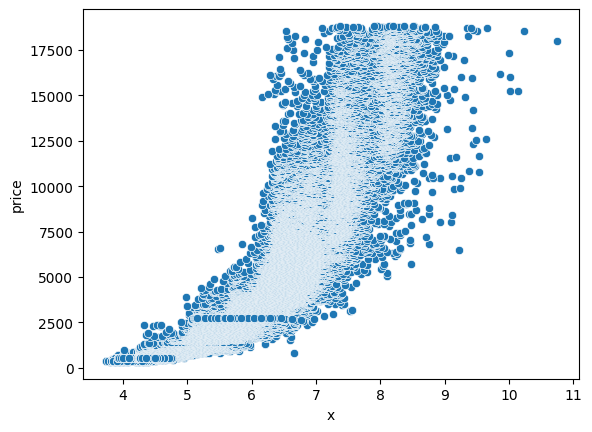

In [ ]:
sns.scatterplot(x=df["x"],y=df["price"])
plt.show()

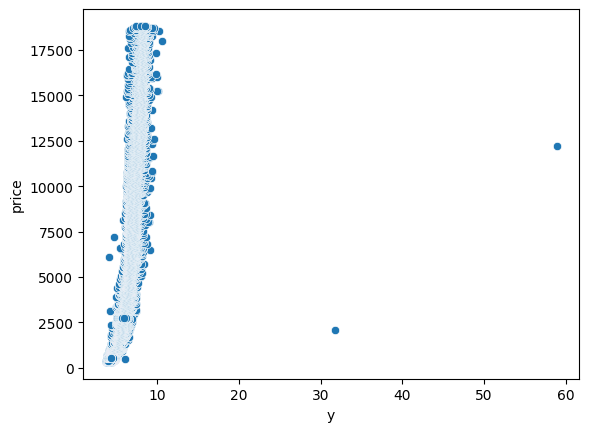

In [ ]:
sns.scatterplot(x=df["y"],y=df["price"])
plt.show()

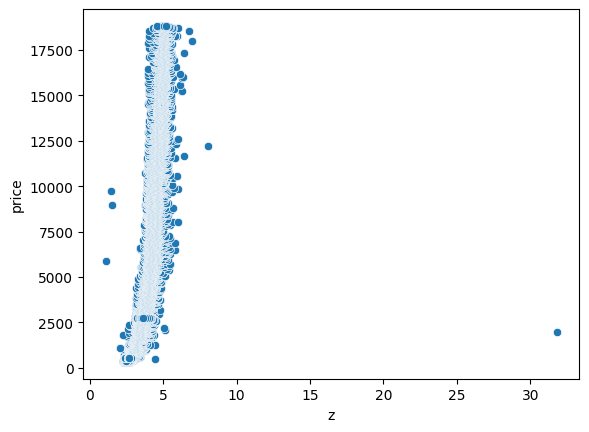

In [ ]:
sns.scatterplot(x=df["z"],y=df["price"])
plt.show()

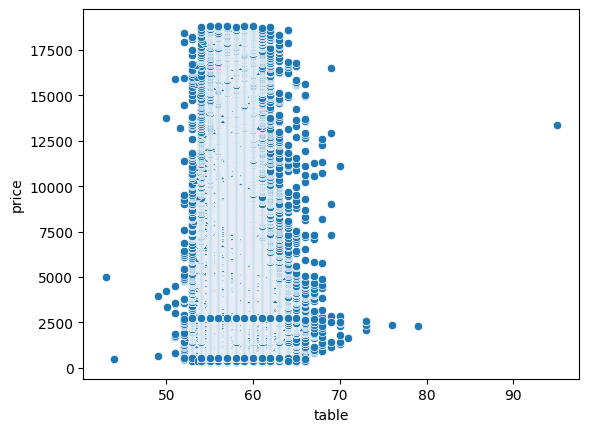

In [ ]:
sns.scatterplot(x=df["table"],y=df["price"])
plt.show()

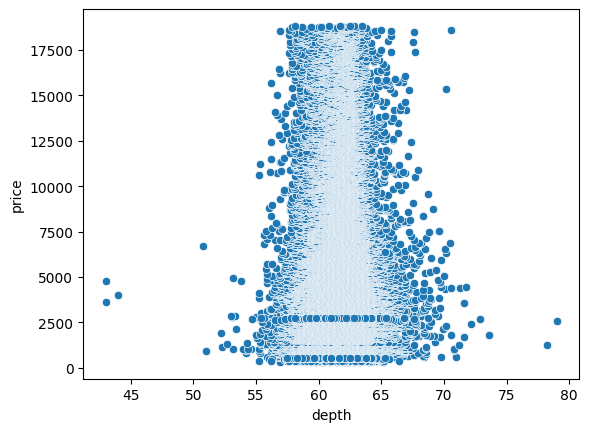

In [ ]:
sns.scatterplot(x=df["depth"],y=df["price"])
plt.show()

In [ ]:
#There are some outliers over here as well, just by looking at the graphs we can eliminate outliers easily
len(df)

53920

In [ ]:
len(df[(df["depth"]<75)&(df["depth"]>45)])

53914

In [ ]:
len(df[(df["table"]<80)&(df["table"]>40)])

53919

In [ ]:
len(df[(df["y"]<30)])

53918

In [ ]:
len(df[(df["z"]<30)&(df["z"]>2)])

53916

In [ ]:
df = df[(df["depth"]<75)&(df["depth"]>45)]
df = df[(df["table"]<80)&(df["table"]>40)]
df = df[(df["y"]<30)]
df = df[(df["z"]<30)&(df["z"]>2)]

In [ ]:
df.describe()

,Unnamed: 0,carat,depth,table,price,x,y,z
count,53907.000000,53907.000000,53907.000000,53907.000000,53907.000000,53907.000000,53907.000000,53907.000000
mean,26971.950804,0.797628,61.749741,57.455948,3930.584470,5.731463,5.733292,3.539441
std,15570.790852,0.473765,1.420119,2.226153,3987.202815,1.119384,1.111252,0.691434
min,1.000000,0.200000,50.800000,43.000000,326.000000,3.730000,3.680000,2.060000
25%,13487.500000,0.400000,61.000000,56.000000,949.000000,4.710000,4.720000,2.910000
50%,26975.000000,0.700000,61.800000,57.000000,2401.000000,5.700000,5.710000,3.530000
75%,40455.500000,1.040000,62.500000,59.000000,5322.000000,6.540000,6.540000,4.040000
max,53940.000000,5.010000,73.600000,79.000000,18823.000000,10.740000,10.540000,6.980000


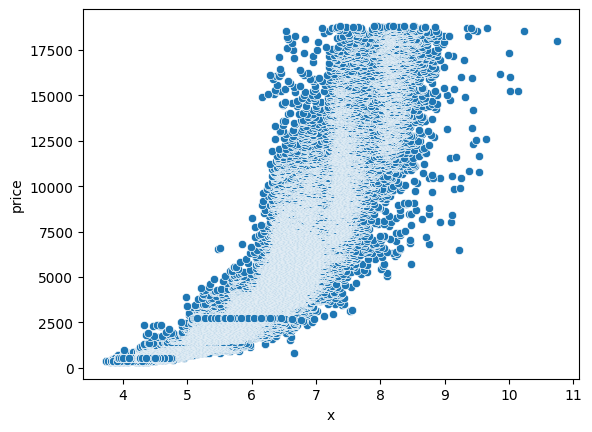

In [ ]:
sns.scatterplot(x=df["x"],y=df["price"])
plt.show()

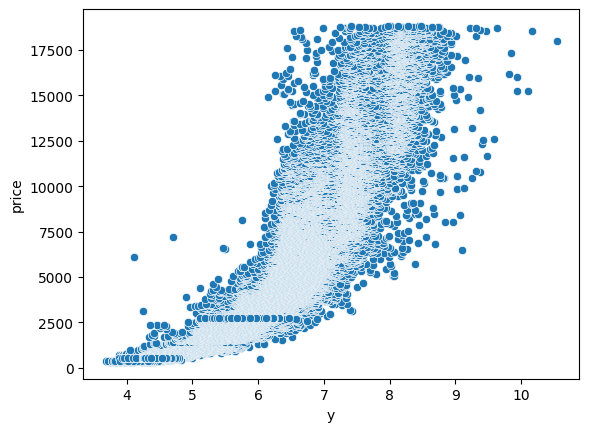

In [ ]:
sns.scatterplot(x=df["y"],y=df["price"])
plt.show()

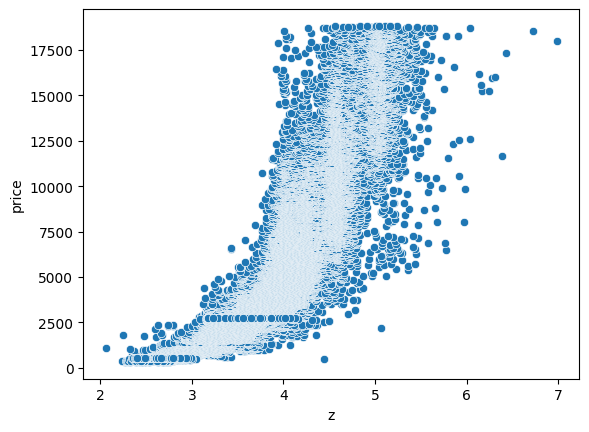

In [ ]:
sns.scatterplot(x=df["z"],y=df["price"])
plt.show()

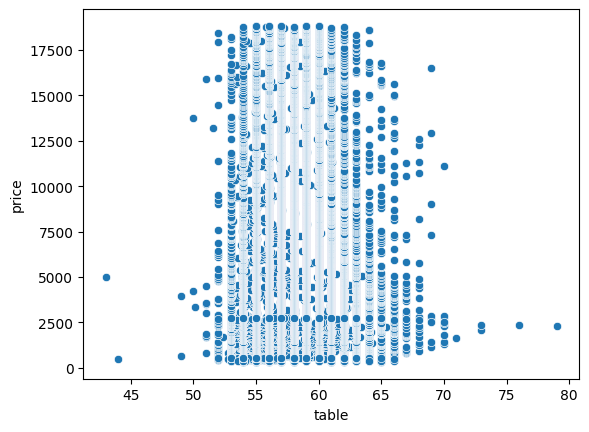

In [ ]:
sns.scatterplot(x=df["table"],y=df["price"])
plt.show()

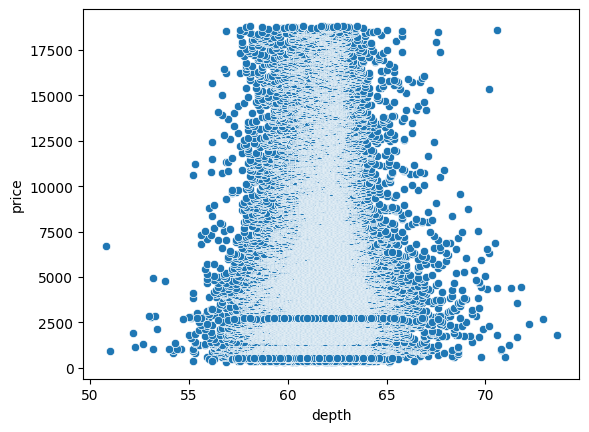

In [ ]:
sns.scatterplot(x=df["depth"],y=df["price"])
plt.show()

In [ ]:
#we should change the object variable to data variable
df["cut"].value_counts()

cut
Ideal        21543
Premium      13779
Very Good    12080
Good          4902
Fair          1603
Name: count, dtype: int64

In [ ]:
df["color"].value_counts()

color
G    11282
E     9792
F     9536
H     8296
D     6774
I     5420
J     2807
Name: count, dtype: int64

In [ ]:
df["clarity"].value_counts()

clarity
SI1     13059
VS2     12250
SI2      9184
VS1      8167
VVS2     5066
VVS1     3654
IF       1790
I1        737
Name: count, dtype: int64

In [ ]:
X=df.drop("price", axis=1)
y=df["price"]

In [ ]:
#before encoding these, i will split this into train-test to avoid data leakage
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y,test_size=0.25, random_state=34)

In [ ]:
from sklearn.preprocessing import LabelEncoder
label_encoder=LabelEncoder()
for col in ['cut', 'color', 'clarity']:
    X_train[col] = label_encoder.fit_transform(X_train[col])
    X_test[col] = label_encoder.transform(X_test[col])
X_train

,Unnamed: 0,carat,cut,color,clarity,depth,table,x,y,z
39611,39612,0.35,2,4,2,62.3,57.0,4.50,4.55,2.82
12326,12327,0.91,1,2,7,62.6,61.0,6.12,6.19,3.85
49040,49041,0.71,0,3,3,64.8,58.0,5.60,5.57,3.62
29199,29200,0.33,2,5,1,61.6,55.0,4.46,4.47,2.75
14482,14483,1.03,3,4,4,61.2,58.0,6.55,6.52,4.00
...,...,...,...,...,...,...,...,...,...,...
28431,28432,0.30,2,0,5,61.3,56.0,4.32,4.36,2.66
22392,22393,2.00,1,3,3,64.3,60.0,7.87,7.83,5.05
43524,43525,0.41,2,3,1,62.0,55.0,4.80,4.81,2.98
38035,38036,0.40,2,3,5,61.0,57.0,4.74,4.77,2.90


In [ ]:
X_train["cut"].value_counts()

cut
2    16130
3    10368
4     9043
1     3687
0     1202
Name: count, dtype: int64

In [ ]:
X_train["color"].value_counts()

color
3    8437
1    7374
2    7091
4    6238
0    4992
5    4165
6    2133
Name: count, dtype: int64

In [ ]:
X_train["clarity"].value_counts()

clarity
2    9812
5    9211
3    6831
4    6144
7    3790
6    2748
1    1347
0     547
Name: count, dtype: int64

In [ ]:
from sklearn.preprocessing import StandardScaler
scaler=StandardScaler()
X_train_scalled=scaler.fit_transform(X_train)
X_test_scaled=scaler.transform(X_test)

mae:  862.331676133134
mse:  1797646.2748497126
score:  0.8856193232665914


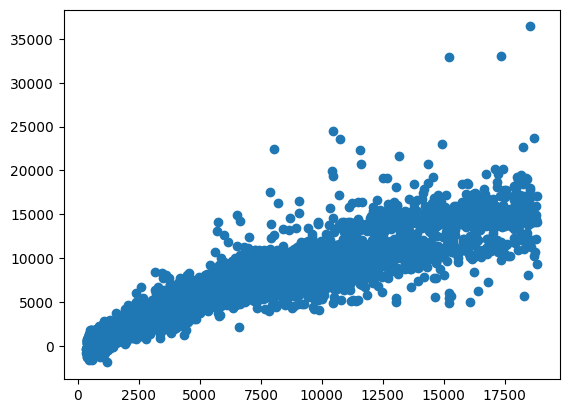

In [ ]:
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score, mean_absolute_error,mean_squared_error
linear=LinearRegression()
linear.fit(X_train_scalled,y_train)
y_pred=linear.predict(X_test_scaled)
mae=mean_absolute_error(y_test, y_pred)
mse=mean_squared_error(y_test,y_pred)
r2=r2_score(y_test,y_pred)
print("mae: ", mae)
print("mse: ", mse)
print("score: ", r2)
plt.scatter(y_test,y_pred)
plt.show()

mae:  1335.07565277389
mse:  7713597.18347873
score:  0.5091990686716314


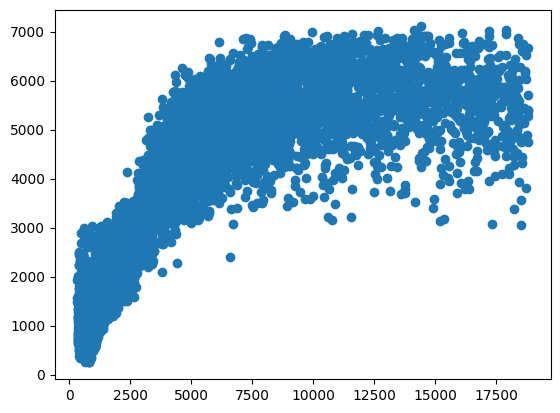

In [ ]:
from sklearn.svm import SVR
from sklearn.metrics import r2_score, mean_absolute_error,mean_squared_error
svr=SVR()
svr.fit(X_train_scalled,y_train)
y_pred2=svr.predict(X_test_scaled)
mae=mean_absolute_error(y_test, y_pred2)
mse=mean_squared_error(y_test,y_pred2)
r2=r2_score(y_test,y_pred2)
print("mae: ", mae)
print("mse: ", mse)
print("score: ", r2)
plt.scatter(y_test,y_pred2)
plt.show()

In [ ]:
# from sklearn.linear_model import LogisticRegression
# log_linear=LogisticRegression()
# from sklearn.metrics import r2_score, mean_absolute_error,mean_squared_error
# log_linear.fit(X_train_scalled,y_train)
# y_pred3=log_linear.predict(X_test_scaled)
# mae=mean_absolute_error(y_test, y_pred3)
# mse=mean_squared_error(y_test,y_pred3)
# r2=r2_score(y_test,y_pred3)
# print("mae: ", mae)
# print("mse: ", mse)
# print("score: ", r2)
# plt.scatter(y_test,y_pred3)
# plt.show()

In [ ]:
# Hyperparameter Tuning using GridSearch CV
from sklearn.model_selection import GridSearchCV
 
# defining parameter range
param_grid = {'C': [0.1, 1, 10, 100, 1000],
              'gamma': [1, 0.1, 0.01, 0.001, 0.0001],
              'kernel': ['rbf','linear']}


In [ ]:
grid = GridSearchCV(SVR(), param_grid, refit = True,verbose = 3) # n_jobs=-1 means use all processor

In [ ]:
grid.fit(X_train_scalled, y_train)

In [ ]:
grid.best_params_

In [ ]:
y_pred4=grid.predict(X_test_scaled)
mae=mean_absolute_error(y_test,y_pred4)
score=r2_score(y_test,y_pred4)
print("Mean absolute error", mae)
print("R2 Score", score)
plt.scatter(y_test,y_pred4)
plt.show()